In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import math
import os
import sys
from matplotlib import pyplot as plt
from pathlib import Path
HOME = "/home/michal/slrm/gen4"
if os.getenv("PLG_GROUPS_STORAGE"):
    HOME = "/net/people/plgrid/plgmichalgodek/workspace/ai-proton-simulations/gen4"
LOGS_PATH = Path(HOME, "tmp", "logs") 


In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
training_data = np.load(Path(HOME,"training_data_g4_batch.npz"))
data_z_dose = training_data["data_z_dose"]
data_z_fluence_protons = training_data["data_z_fluence_protons"]
data_z_dlet_protons = training_data["data_z_dlet_protons"]
data_r_dose = training_data["data_r_dose"]
data_r_fluence_protons = training_data["data_r_fluence_protons"]
data_r_dlet_protons = training_data["data_r_dlet_protons"]
data_x = training_data["data_x"]

print(f"Training on energies [{data_x[0],data_x[1]}...{data_x[-2],data_x[-1]}")
x_min, x_max = np.min(data_x), np.max(data_x)

# per-series maxima
max_z_dose = np.max(data_z_dose)
max_r_dose = np.max(data_r_dose)
# overall max (kept for compatibility)
max_dose = max(max_z_dose, max_r_dose)

max_z_fluence_protons = np.max(data_z_fluence_protons)
max_r_fluence_protons = np.max(data_r_fluence_protons)
max_fluence_protons = max(max_z_fluence_protons, max_r_fluence_protons)

max_z_dlet_protons = np.max(data_z_dlet_protons)
max_r_dlet_protons = np.max(data_r_dlet_protons)
max_dlet_protons = max(max_z_dlet_protons, max_r_dlet_protons)

normalized_x = (data_x - x_min) / (x_max-x_min)

# normalized per-series
normalized_data_z_dose = data_z_dose / max_z_dose
normalized_data_r_dose = data_r_dose / max_r_dose

normalized_data_z_fluence_protons = data_z_fluence_protons / max_z_fluence_protons
normalized_data_r_fluence_protons = data_r_fluence_protons / max_r_fluence_protons

normalized_data_z_dlet_protons = data_z_dlet_protons / max_z_dlet_protons
normalized_data_r_dlet_protons = data_r_dlet_protons / max_r_dlet_protons


# test_data = np.load(Path(HOME, "test_data_g3batch10.npz"))
# data_z_dose_test = test_data["data_z_dose_test"]
# data_z_fluence_protons_test = test_data["data_z_fluence_protons_test"]
# data_z_dlet_protons_test = test_data["data_z_dlet_protons_test"]
# data_r_dose_test = test_data["data_r_dose_test"]
# data_r_fluence_protons_test = test_data["data_r_fluence_protons_test"]
# data_r_dlet_protons_test = test_data["data_r_dlet_protons_test"]
# data_x_test = test_data["data_x_test"]

# normalized_x_test = (data_x_test - x_min) / (x_max-x_min)
# normalized_data_z_dose_test = data_z_dose_test / max_z_dose
# normalized_data_r_dose_test = data_r_dose_test / max_r_dose
# normalized_data_z_fluence_protons_test = data_z_fluence_protons_test / max_z_fluence_protons
# normalized_data_r_fluence_protons_test = data_r_fluence_protons_test / max_r_fluence_protons
# normalized_data_z_dlet_protons_test = data_z_dlet_protons_test / max_z_dlet_protons
# normalized_data_r_dlet_protons_test = data_r_dlet_protons_test / max_r_dlet_protons      
seeds_per_energy = 0
for i,x in enumerate(data_x.reshape(-1)):
    if float(x) == data_x[0]:
        seeds_per_energy += 1
    else:
        break
print(f"Seeds per energy: {seeds_per_energy}")

n_samples = len(data_x)

Device: cpu
Training on energies [(np.float64(20.0), np.float64(20.0))...(np.float64(250.0), np.float64(250.0))
Seeds per energy: 30


# Plot all data 

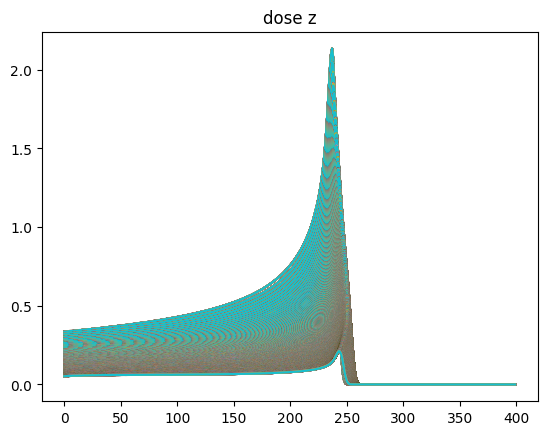

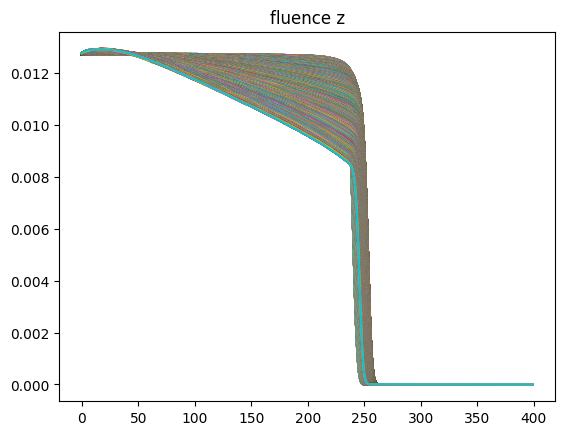

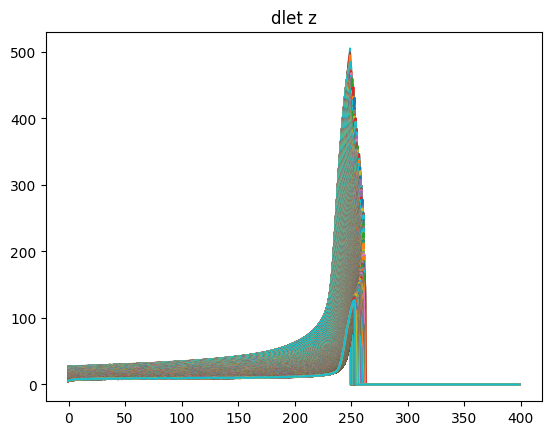

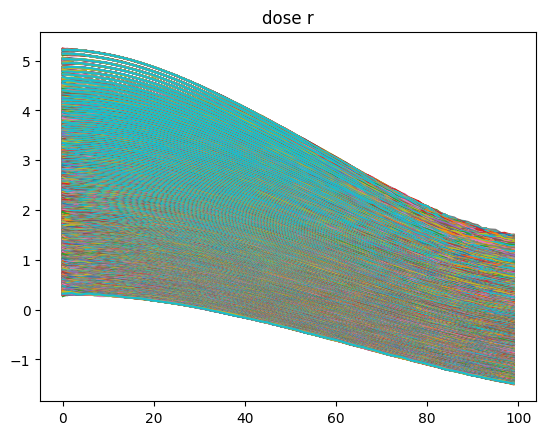

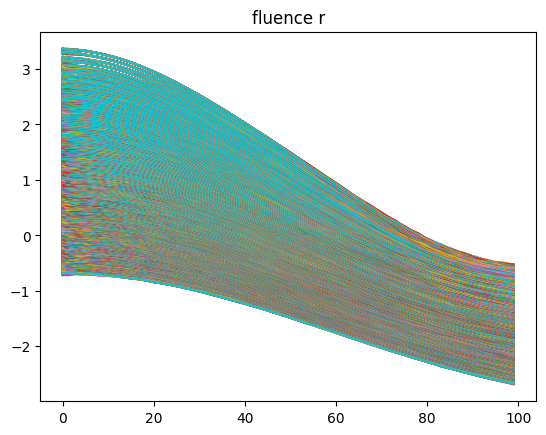

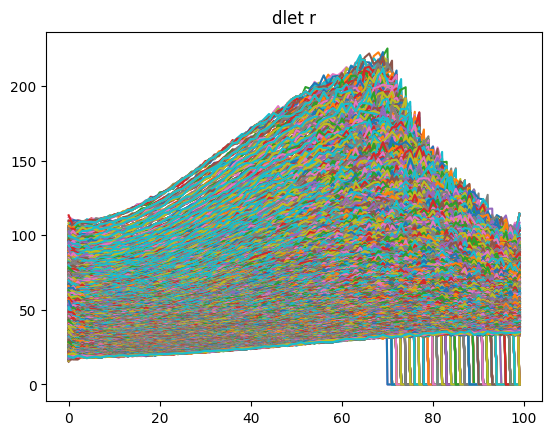

In [3]:
every_nth = 30
for i in data_z_dose[::every_nth]:
    plt.title("dose z")
    plt.plot(i)
plt.show()
for i in data_z_fluence_protons[::every_nth]:
    plt.title("fluence z")
    plt.plot(i)
plt.show()
for i in data_z_dlet_protons[::every_nth]:
    plt.title("dlet z")
    plt.plot(i)
plt.show()
for i in data_r_dose[::every_nth]:
    plt.title("dose r")
    # plt.yscale("log")
    plt.plot(i)
plt.show()
for i in data_r_fluence_protons[::every_nth]:
    plt.title("fluence r")
    # plt.yscale("log")
    plt.plot(i)
plt.show()
for i in data_r_dlet_protons[::every_nth]:
    plt.title("dlet r")
    plt.plot(i)
plt.show()

In [4]:
Y_z = torch.stack([
    torch.tensor(normalized_data_z_dose, dtype=torch.float32),
    torch.tensor(normalized_data_z_fluence_protons, dtype=torch.float32),
    torch.tensor(normalized_data_z_dlet_protons, dtype=torch.float32),
], dim=1).to(device)

Y_r =torch.stack([
    torch.tensor(normalized_data_r_dose, dtype=torch.float32),
    torch.tensor(normalized_data_r_fluence_protons, dtype=torch.float32),
    torch.tensor(normalized_data_r_dlet_protons, dtype=torch.float32),
], dim=1).to(device)

X_tensor = torch.tensor(normalized_x, dtype=torch.float32).to(device)
n_samples = n_samples = len(X_tensor)

In [5]:
import torch
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_z = 400
        self.n_r = 100

        self.trunk = nn.Sequential(
            nn.Linear(1, self.hidden_dim),
            nn.SiLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.SiLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.SiLU(),
        )

        # depth heads
        self.head_dose_z = nn.Sequential(
            nn.Linear(self.hidden_dim, self.n_z),
            nn.Softplus()
        )
        self.head_fluence_z = nn.Sequential(
            nn.Linear(self.hidden_dim, self.n_z),
            nn.Softplus()
        )
        self.head_dlet_z = nn.Sequential(
            nn.Linear(self.hidden_dim, self.n_z),
            nn.Softplus()
        )

        # lateral heads
        self.head_dose_r = nn.Linear(self.hidden_dim, self.n_r)
        self.head_fluence_r = nn.Linear(self.hidden_dim, self.n_r)
        self.head_dlet_r = nn.Sequential(
            nn.Linear(self.hidden_dim, self.n_r),
            nn.Softplus()
        )

    def forward(self, energy: torch.Tensor):
        if energy.dim() == 1:
            energy = energy.unsqueeze(-1)

        features = self.trunk(energy)

        dose_z = self.head_dose_z(features)
        fluence_z = self.head_fluence_z(features)
        dlet_z = self.head_dlet_z(features)

        dose_r = self.head_dose_r(features)
        fluence_r = self.head_fluence_r(features)
        dlet_r = self.head_dlet_r(features)

        return {
            "dose_z": dose_z,
            "fluence_z": fluence_z,
            "dlet_z": dlet_z,
            "dose_r": dose_r,
            "fluence_r": fluence_r,
            "dlet_r": dlet_r,
        }

In [9]:
def loss_fn(pred, target):
    # target is a tuple: (Y_z_batch, Y_r_batch)
    # Y_z_batch shape: (batch, 3, n_z), Y_r_batch shape: (batch, 3, n_r)
    y_z, y_r = target

    dose_z_target = y_z[:, 0, :]
    fluence_z_target = y_z[:, 1, :]
    dlet_z_target = y_z[:, 2, :]
    
    dose_r_target = y_r[:, 0, :]
    fluence_r_target = y_r[:, 1, :]
    dlet_r_target = y_r[:, 2, :]

    loss_dose_z = ((pred["dose_z"] - dose_z_target) ** 2).mean()
    loss_fluence_z = ((pred["fluence_z"] - fluence_z_target) ** 2).mean()
    loss_dlet_z = ((pred["dlet_z"] - dlet_z_target) ** 2).mean()
    
    loss_dose_r = ((pred["dose_r"] - dose_r_target) ** 2).mean()
    loss_fluence_r = ((pred["fluence_r"] - fluence_r_target) ** 2).mean()
    loss_dlet_r = ((pred["dlet_r"] - dlet_r_target) ** 2).mean()
    
    return (
        loss_dose_z +
        loss_fluence_z +
        loss_dlet_z +
        loss_dose_r +
        loss_fluence_r +
        loss_dlet_r
    )

model = Model().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5000)
criterion = nn.MSELoss()
start_training = time.time()

total_epochs = 300
batch_size = 100
for epoch in range(total_epochs):
    train_loss = 0.0
    perm = torch.randperm(n_samples)
    for i in range(0, n_samples, batch_size):
        idx = perm[i:i+batch_size]
        x_batch, y_batch = X_tensor[idx], (Y_z[idx], Y_r[idx])

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    num_batches = math.ceil(n_samples / batch_size)
    train_loss /= num_batches
    current_lr = optimizer.param_groups[0]['lr']

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:>4d} | ",
            f"Train loss: {train_loss:.4e} | ",
            f"LR: {current_lr:.2e}",
            f"Time: {time.time()-start_training:.2f}"
        )
        # with open(LOGS_PATH,"a+") as logs_file:
        #     logs_file.write(
        #         f"Epoch {epoch:>4d} | Train loss: {train_loss:.8e}  | LR: {current_lr:.2e} | Time: {time.time()-start_training:.2f}\n"
        #     )

Epoch    0 |  Train loss: 3.8221e-01 |  LR: 1.00e-03 Time: 0.58
Epoch   50 |  Train loss: 6.6767e-04 |  LR: 1.00e-03 Time: 17.13
Epoch  100 |  Train loss: 4.4643e-04 |  LR: 1.00e-03 Time: 33.34
Epoch  150 |  Train loss: 3.9154e-04 |  LR: 1.00e-03 Time: 51.07
Epoch  200 |  Train loss: 3.7473e-04 |  LR: 1.00e-03 Time: 67.29
Epoch  250 |  Train loss: 3.5016e-04 |  LR: 1.00e-03 Time: 84.90


In [ ]:
model.eval()
X_norm_unique = np.unique(  ).reshape(-1, 1)
with torch.no_grad():
    predictions = model(torch.from_numpy(X_norm_unique.astype(np.float32)).to(device))

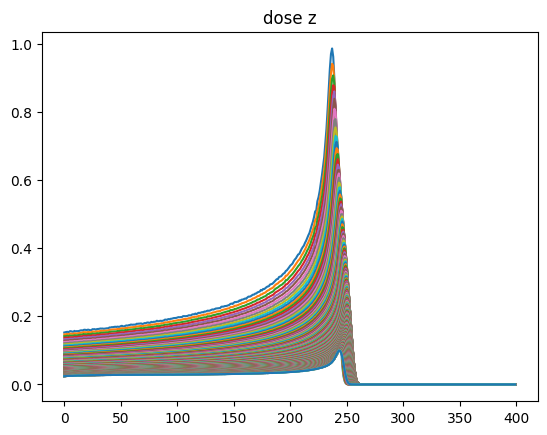

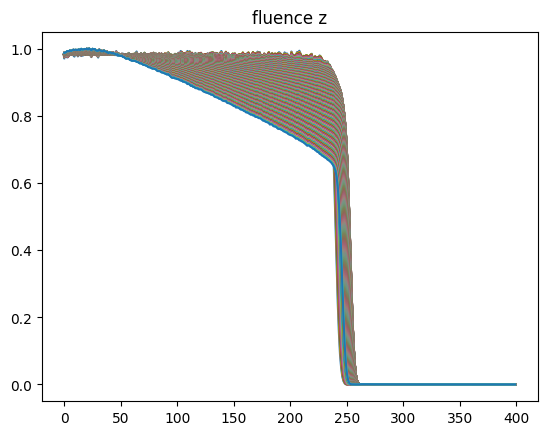

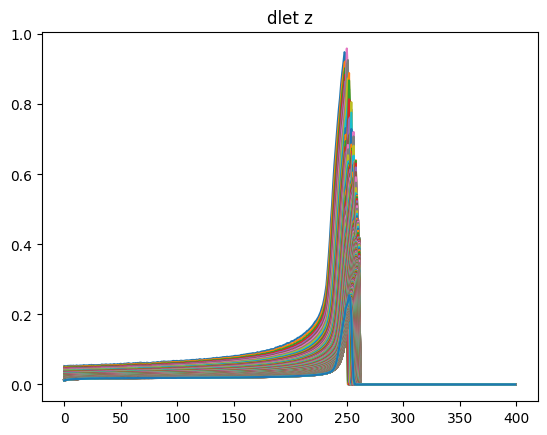

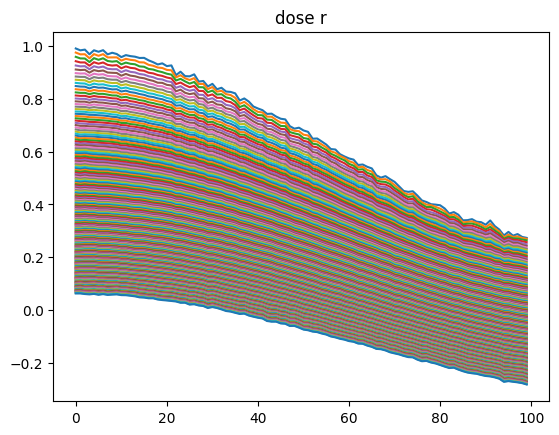

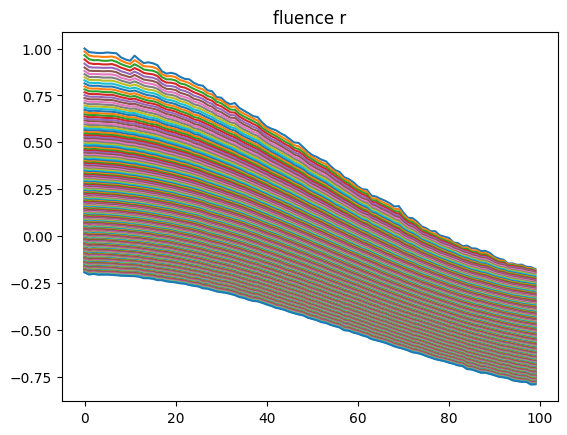

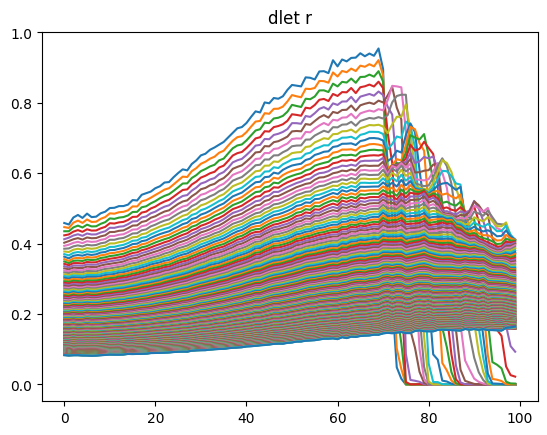

In [16]:
for i in range(len(predictions["dose_z"])):
    plt.title("dose z")
    plt.plot(predictions["dose_z"][i].detach().cpu().numpy())
plt.show()
for i in range(len(predictions["fluence_z"])):
    plt.title("fluence z")
    plt.plot(predictions["fluence_z"][i].detach().cpu().numpy())
plt.show()
for i in range(len(predictions["dlet_z"])):
    plt.title("dlet z")
    plt.plot(predictions["dlet_z"][i].detach().cpu().numpy())
plt.show()
for i in range(len(predictions["dose_r"])):
    plt.title("dose r")
    plt.plot(predictions["dose_r"][i].detach().cpu().numpy())
plt.show()
for i in range(len(predictions["fluence_r"])):
    plt.title("fluence r")
    plt.plot(predictions["fluence_r"][i].detach().cpu().numpy())
plt.show()
for i in range(len(predictions["dlet_r"])):
    plt.title("dlet r")
    plt.plot(predictions["dlet_r"][i].detach().cpu().numpy())
plt.show()